# BrandPulse AI — Notebook 02
## Deep Learning: Embedding + Bi-Directional LSTM

Where the classical model (Notebook 01) treats a tweet as a *bag of words* and ignores
order, an LSTM reads the tweet **as a sequence** and remembers context. "not happy" and
"happy not" are identical to TF-IDF but different to an LSTM.

**Architecture:** `Embedding → SpatialDropout → Bi-LSTM → Dense(softmax)`

We reuse the **same cleaned data** (`data/clean_tweets.csv`) and the **same train/test split
seed** as Notebook 01, so the Phase 3 comparison is strictly apples-to-apples.


### Setup & imports

> **macOS arm64 note:** we import TensorFlow *before* pandas. pandas 2.x loads
> pyarrow, whose bundled `libarrow` ships its own `absl` synchronization symbols; if
> they load before TF, `model.fit()` deadlocks at 0% CPU. Import order fixes it.

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf            # MUST come before pandas/pyarrow
tf.config.threading.set_intra_op_parallelism_threads(4)
tf.config.threading.set_inter_op_parallelism_threads(2)

import sys, json
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, Bidirectional, LSTM, Dense,
                                      Dropout, SpatialDropout1D)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)

from src.preprocess import clean_tweet, LABELS, ID2LABEL

tf.random.set_seed(42)
np.random.seed(42)
sns.set_style('whitegrid')
print('TensorFlow', tf.__version__)

TensorFlow 2.21.0


### 1. Load cleaned data + identical split

In [2]:
df = pd.read_csv('../data/clean_tweets.csv')
df = df[df['clean_text'].notna() & df['clean_text'].str.strip().astype(bool)].copy()

X = df['clean_text'].to_numpy(dtype=object)
y = df['label'].to_numpy(dtype=int)

# SAME seed/stratify as Notebook 01 -> same test set -> fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train)}  Test: {len(X_test)}')

Train: 11686  Test: 2922


### 2. Tokenize & pad sequences
Deep nets need fixed-length integer sequences. We build a vocabulary from the training set
only (no leakage), map each word to an integer, then pad/truncate every tweet to a fixed
length.

In [3]:
VOCAB_SIZE = 10000
MAX_LEN = 40   # 95th percentile of tweet length is well under this

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

Xtr_seq = pad_sequences(tokenizer.texts_to_sequences(X_train),
                        maxlen=MAX_LEN, padding='post', truncating='post')
Xte_seq = pad_sequences(tokenizer.texts_to_sequences(X_test),
                        maxlen=MAX_LEN, padding='post', truncating='post')

ytr_cat = to_categorical(y_train, num_classes=3)
yte_cat = to_categorical(y_test, num_classes=3)

print('Padded train shape:', Xtr_seq.shape)
print('Example sequence:', Xtr_seq[0][:15], '...')

Padded train shape: (11686, 40)
Example sequence: [  13   10  161  764   14    5  361   18 1550 1867   40  820    0    0
    0] ...


### 3. Handle class imbalance with class weights

In [4]:
weights = compute_class_weight('balanced', classes=np.array([0,1,2]), y=y_train)
class_weight = {i: w for i, w in enumerate(weights)}
print('Class weights:', {ID2LABEL[i]: round(w,3) for i,w in class_weight.items()})

Class weights: {'negative': np.float64(0.531), 'neutral': np.float64(1.583), 'positive': np.float64(2.064)}


### 4. Build the model
`Embedding` learns a dense 64-d vector per word. `Bidirectional(LSTM)` reads the sequence
forward AND backward, so context from both directions informs each step. `Dropout` /
`SpatialDropout1D` fight overfitting on our small dataset.

In [5]:
model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=64),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64)),
    Dense(32, activation='relu'),
    Dropout(0.4),
    Dense(3, activation='softmax'),
])
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.build(input_shape=(None, MAX_LEN))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 40, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 40, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 710,275 (2.71 MB)

 Trainable params: 710,275 (2.71 MB)

 Non-trainable params: 0 (0.00 B)

### 5. Train (with early stopping to prevent overfitting)
We monitor validation loss and restore the best weights — the brief's Week-3 instruction.

In [6]:
early = EarlyStopping(monitor='val_loss', patience=3,
                     restore_best_weights=True, verbose=1)

history = model.fit(
    Xtr_seq, ytr_cat,
    validation_split=0.1,
    epochs=12,
    batch_size=128,
    class_weight=class_weight,
    callbacks=[early],
    verbose=2)

Epoch 1/12


83/83 - 5s - 55ms/step - accuracy: 0.5464 - loss: 0.9818 - val_accuracy: 0.7006 - val_loss: 0.7187


Epoch 2/12


83/83 - 3s - 31ms/step - accuracy: 0.7457 - loss: 0.7093 - val_accuracy: 0.7656 - val_loss: 0.6117


Epoch 3/12


...

83/83 - 3s - 32ms/step - accuracy: 0.8753 - loss: 0.3645 - val_accuracy: 0.7639 - val_loss: 0.6772


Epoch 6/12


83/83 - 2s - 29ms/step - accuracy: 0.8952 - loss: 0.3058 - val_accuracy: 0.7596 - val_loss: 0.7258


Epoch 6: early stopping


Restoring model weights from the end of the best epoch: 3.


### 6. Learning curves — did we overfit?

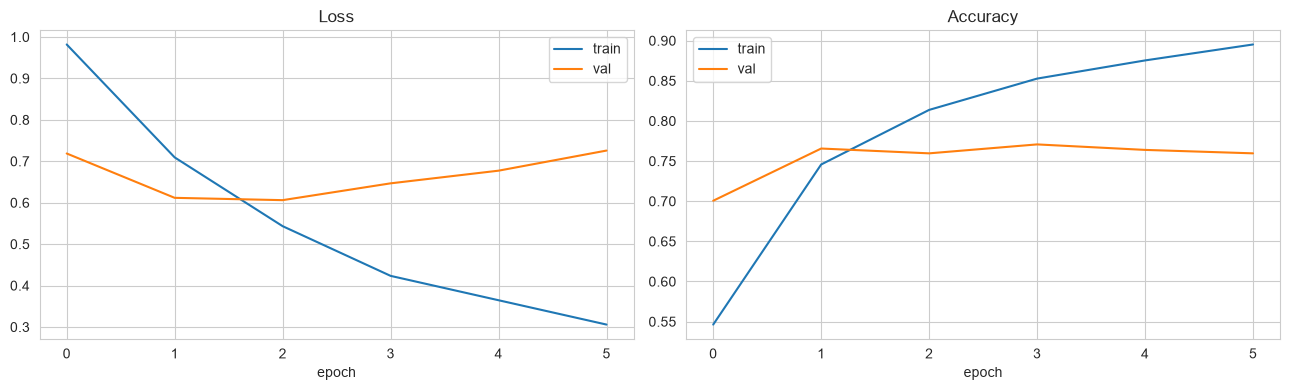

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(history.history['loss'], label='train')
ax[0].plot(history.history['val_loss'], label='val')
ax[0].set_title('Loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(history.history['accuracy'], label='train')
ax[1].plot(history.history['val_accuracy'], label='val')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend()
plt.tight_layout()
plt.savefig('../reports/lstm_learning_curves.png', dpi=110, bbox_inches='tight')
plt.show()

### 7. Evaluate on the held-out test set

In [8]:
probs = model.predict(Xte_seq, verbose=0)
pred_lstm = probs.argmax(axis=1)

acc = accuracy_score(y_test, pred_lstm)
mf1 = f1_score(y_test, pred_lstm, average='macro')
wf1 = f1_score(y_test, pred_lstm, average='weighted')
print('Accuracy :', round(acc, 4))
print('Macro F1 :', round(mf1, 4))
print()
print(classification_report(y_test, pred_lstm, target_names=LABELS))

Accuracy : 0.7741
Macro F1 : 0.7153

              precision    recall  f1-score   support

    negative       0.89      0.83      0.86      1835
     neutral       0.61      0.57      0.59       615
    positive       0.60      0.82      0.69       472

    accuracy                           0.77      2922
   macro avg       0.70      0.74      0.72      2922
weighted avg       0.79      0.77      0.78      2922



### 8. Confusion matrix — LSTM

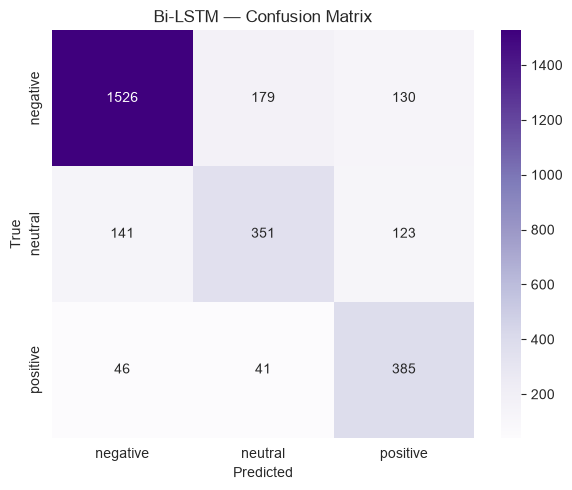

In [9]:
cm = confusion_matrix(y_test, pred_lstm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=LABELS, yticklabels=LABELS)
plt.title('Bi-LSTM — Confusion Matrix')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/cm_lstm.png', dpi=110, bbox_inches='tight')
plt.show()

### 9. Custom inference test (same sentences as the classical model)

In [10]:
def predict_lstm(text):
    seq = pad_sequences(tokenizer.texts_to_sequences([clean_tweet(text)]),
                        maxlen=MAX_LEN, padding='post', truncating='post')
    p = model.predict(seq, verbose=0)[0]
    i = int(p.argmax())
    return ID2LABEL[i], float(p[i])

tests = [
    "The service was amazing!",
    "I waited 4 hours just to get a cold burger.",
    "@united my flight is delayed again, not happy at all",
    "Thanks for the smooth check-in, great crew!",
    "What time does the gate open?",
]
for t in tests:
    label, conf = predict_lstm(t)
    print(f'[{label:>8}  {conf:.0%}]  {t}')

[positive  90%]  The service was amazing!
[negative  73%]  I waited 4 hours just to get a cold burger.
[negative  61%]  @united my flight is delayed again, not happy at all
[positive  100%]  Thanks for the smooth check-in, great crew!
[ neutral  56%]  What time does the gate open?


### 10. Persist the LSTM artifacts

In [11]:
import pickle
model.save('../models/lstm_model.keras')
with open('../models/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
with open('../models/lstm_config.json', 'w') as f:
    json.dump({'max_len': MAX_LEN, 'vocab_size': VOCAB_SIZE}, f)

lstm_metrics = {'BiLSTM': {
    'accuracy': round(acc, 4),
    'macro_f1': round(mf1, 4),
    'weighted_f1': round(wf1, 4)}}
with open('../reports/lstm_metrics.json', 'w') as f:
    json.dump(lstm_metrics, f, indent=2)
print('Saved LSTM model, tokenizer, config, metrics.')
print(json.dumps(lstm_metrics, indent=2))

Saved LSTM model, tokenizer, config, metrics.
{
  "BiLSTM": {
    "accuracy": 0.7741,
    "macro_f1": 0.7153,
    "weighted_f1": 0.7768
  }
}


---
### Phase 2B complete ✅
- Model → `models/lstm_model.keras`, tokenizer → `models/tokenizer.pkl`
- Metrics → `reports/lstm_metrics.json`
- Curves & confusion matrix → `reports/`

**Next:** Phase 3 compares Classical vs LSTM head-to-head.